# De Novo Lead-Binding Protein Design — RFD3 Double-Motif Pipeline

```text
RFD3  →  ProteinMPNN  →  RF3
```

Adapted for the **double-motif lead-sensing project**. Two copies of the Pb²⁺-Cys₃ motif from
PbrR691 / 5GPE are embedded in a single de novo scaffold.

Key differences from the single-motif pipeline:

- Input JSONs come from `02_prepare_rfd3_double_inputs.sh` (not `01_prepare_rfd3_inputs.sh`).
- Each JSON in `rfdiffusion_inputs/per_design/` contains one double-motif design.
- The input PDB is already embedded in the payload (`payload["input"]`); no separate context PDB lookup is needed.
- Both motif copies share the same open-space direction (outward vector).
- Chains: original motif on C/D, copied motif on X/Y (default).
- MPNN fixes residues from **both** motif copies.
- RF3 validation checks Cys3 conservation in both copies independently.

## How to run

1. Run `02_prepare_rfd3_double_inputs.sh` first.
2. Set `PREP_EXPERIMENT` below to the folder it wrote (e.g. `exp_doubles_02`).
3. Run cells top to bottom. GPU stages print the `bsub < ...` command — submit and wait before continuing.


## 0. Setup: imports, repo paths, run configuration

In [1]:
# --- Core ---
import os
import re
import csv
import glob
import json
import math
import gzip
import shutil
from pathlib import Path
from copy import deepcopy

# --- Data / plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


def find_repo_root(start: Path) -> Path:
    """Find the lead_sensoring project root from the current notebook directory."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_structure = (candidate / "data" / "raw" / "5gpe.cif").exists()
        has_scripts = (candidate / "scripts").is_dir()
        if has_structure and has_scripts:
            return candidate
    raise RuntimeError(
        f"Could not find the project root from {start}. "
        "Run this notebook from the lead_sensoring root or from lead_sensoring/scripts."
    )


REPO_ROOT = find_repo_root(Path.cwd())
STRUCTURE_CIF = (REPO_ROOT / "data" / "raw" / "5gpe.cif").resolve()

sys_path_candidate = REPO_ROOT / "scripts" / "lib"
if str(sys_path_candidate) not in os.sys.path:
    os.sys.path.insert(0, str(sys_path_candidate))

print("Repo root :", REPO_ROOT)
print("5GPE CIF  :", STRUCTURE_CIF)
print("User      :", os.environ.get("USER", "?"))


Repo root : /dtu/blackhole/00/222976/lead_sensoring
5GPE CIF  : /dtu/blackhole/00/222976/lead_sensoring/data/raw/5gpe.cif
User      : s252608


In [2]:
# -------------------------------------------------------------------------
# User-editable configuration
# -------------------------------------------------------------------------

# Experiment produced by 02_prepare_rfd3_double_inputs.sh
PREP_EXPERIMENT = "exp_doubles_01"

# Downstream RFD3/MPNN/RF3 run folder created by this notebook
RUN_EXPERIMENT = f"{PREP_EXPERIMENT}_rfd3_mpnn_rf3"

# LSF / environment settings
QUEUE = "c27666"
CONDA_SH = "/dtu/projects/dbl/foundry/miniforge3/etc/profile.d/conda.sh"
RFD3_CONDA_ENV = "rfd3"
MPNN_CONDA_ENV = "rfd3"

# Weights
RFD3_CKPT_PATH = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/rfd3_latest.ckpt"
PROTEINMPNN_CKPT = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/proteinmpnn_v_48_020.pt"
RF3_RELEASE = "/dtu/projects/dbl/rf3/release"
RF3_CKPT_PATH = "/dtu/blackhole/00/c27666/27666_Protein_Design/weights/rf3_foundry_01_24_latest_remapped.ckpt"
RF3_NUM_STEPS = 50

# SpyTag
SPYTAG_LINKER = "GSGSGS"
SPYTAG_SEQ = "AHIVMVDAYKPTK"
SPYTAG = SPYTAG_LINKER + SPYTAG_SEQ

# RFD3 sampling
DIFFUSION_BATCH_SIZE = 1
N_BATCHES = 4

# ProteinMPNN
MPNN_SEED = 42
MPNN_BATCH_SIZE = 2
MPNN_NUMBER_OF_BATCHES = 2
CHAINS_TO_DESIGN = "A"

# Double-motif chain IDs.
# Original motif: MOTIF1_CHAINS (same as single-motif pipeline, from 5GPE).
# Copied motif:   MOTIF2_CHAINS (assigned by prepare script, default X/Y).
MOTIF1_CHAINS = ["C", "D"]   # original Cys3 motif from 5GPE
MOTIF2_CHAINS = ["X", "Y"]   # copied motif

print("Preparation experiment:", PREP_EXPERIMENT)
print("Run experiment        :", RUN_EXPERIMENT)
print("SpyTag                :", SPYTAG, f"({len(SPYTAG)} aa)")
print("Motif 1 chains        :", MOTIF1_CHAINS)
print("Motif 2 chains        :", MOTIF2_CHAINS)


Preparation experiment: exp_doubles_01
Run experiment        : exp_doubles_01_rfd3_mpnn_rf3
SpyTag                : GSGSGSAHIVMVDAYKPTK (19 aa)
Motif 1 chains        : ['C', 'D']
Motif 2 chains        : ['X', 'Y']


In [3]:
# -------------------------------------------------------------------------
# Working directories
# -------------------------------------------------------------------------

PREP_ROOT = REPO_ROOT / "work" / PREP_EXPERIMENT
if not PREP_ROOT.exists():
    available = sorted(p.name for p in (REPO_ROOT / "work").glob("exp*"))
    raise RuntimeError(
        f"PREP_ROOT does not exist: {PREP_ROOT}\n"
        f"Available work experiments: {available}"
    )

WORK = REPO_ROOT / "work" / RUN_EXPERIMENT

subdirs = [
    "cmds", "submit", "logs", "configs", "scores",
    "diffusion_out", "mpnn_out", "rf3_out", "best_binders",
]
for subdir in subdirs:
    (WORK / subdir).mkdir(parents=True, exist_ok=True)

cmds_dir = WORK / "cmds"
submit_dir = WORK / "submit"
logs_dir = WORK / "logs"
configs_dir = WORK / "configs"
scores_dir = WORK / "scores"
diffusion_out_dir = WORK / "diffusion_out"
mpnn_out_dir = WORK / "mpnn_out"
rf3_out_dir = WORK / "rf3_out"
best_binders_dir = WORK / "best_binders"

print("Preparation root:", PREP_ROOT)
print("Working dir     :", WORK)


Preparation root: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01
Working dir     : /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3


## 1. Load prepared double-motif RFD3 inputs

Reads the per-design JSONs from  produced by
.

Each JSON already contains the path to the double-motif PDB (),
so no separate context PDB lookup is needed.


In [4]:
def load_payload(path: Path) -> tuple[str, dict]:
    """Load one RFD3 input JSON and return its design name and payload."""
    with path.open() as handle:
        data = json.load(handle)
    if len(data) != 1:
        raise ValueError(f"Expected exactly one design per RFD3 input JSON: {path}")
    design_name = next(iter(data))
    return design_name, data[design_name]


def classify_contig_style(contig: str) -> str:
    """Classify whether an RFD3 contig is binder-style or monomeric-style."""
    if "/0" in contig:
        return "binder"
    return "monomeric"


def condition_label_from_name(design_name: str) -> str:
    """Build a stable condition label from the double-motif design name.

    Example input:
        5gpe_pb_motif_r5_ori5A_single_double_ori5A_rot180deg

    Extracts:
        ori5A_rot180deg
    """
    match = re.search(r"(ori\w+_rot\w+)", design_name)
    if match:
        return match.group(1)
    return design_name


def write_runtime_rfd3_json(
    design_name: str,
    payload: dict,
    condition: str,
    outdir: Path,
) -> Path:
    """Write a runtime RFD3 JSON. The input PDB path comes from the payload itself."""
    outdir.mkdir(parents=True, exist_ok=True)
    runtime_json = outdir / f"rfd3_input_{condition}.json"
    with runtime_json.open("w") as handle:
        json.dump({design_name: payload}, handle, indent=2)
    return runtime_json.resolve()


# Discover per-design JSONs produced by 02_prepare_rfd3_double_inputs.sh.
per_design_dir = PREP_ROOT / "rfdiffusion_inputs" / "per_design"
per_design_jsons = sorted(per_design_dir.glob("*.json"))

if not per_design_jsons:
    raise RuntimeError(
        f"No per-design JSONs found under {per_design_dir}.\n"
        "Run 02_prepare_rfd3_double_inputs.sh first."
    )

runtime_json_dir = configs_dir / "rfd3_runtime_inputs"
manifest_rows = []

for input_json in per_design_jsons:
    design_name, payload = load_payload(input_json)
    contig = payload["contig"]
    contig_style = classify_contig_style(contig)
    condition = condition_label_from_name(design_name)

    # The double-motif PDB is embedded in the payload.
    input_pdb = Path(payload["input"])
    if not input_pdb.exists():
        print(f"[WARNING] PDB not found: {input_pdb}")

    runtime_json = write_runtime_rfd3_json(
        design_name=design_name,
        payload=payload,
        condition=condition,
        outdir=runtime_json_dir,
    )

    print(f"[OK] {condition}")
    print(f"     contig = {contig}")
    print(f"     input  = {input_pdb.name}")

    manifest_rows.append(
        {
            "design_name": design_name,
            "condition": condition,
            "contig": contig,
            "contig_style": contig_style,
            "input_pdb": str(input_pdb),
            "runtime_input_json": str(runtime_json),
            "has_select_fixed_atoms": "select_fixed_atoms" in payload,
            "ori_token": str(payload.get("ori_token", "")),
        }
    )

rfd3_manifest = pd.DataFrame(manifest_rows)
manifest_csv = configs_dir / "rfd3_input_manifest.csv"
rfd3_manifest.to_csv(manifest_csv, index=False)

print(f"\nManifest: {manifest_csv}")
print(f"Total conditions: {len(rfd3_manifest)}")
rfd3_manifest[["condition", "contig"]].head(10)


[OK] ori13A_single_double_ori13A_rot180deg
     contig = 10-50,C72-84,5-20,D107-128,5-20,X72-84,5-20,Y107-128,10-50
     input  = 5gpe_pb_motif_r5_ori13A_single_double_ori13A_rot180deg.pdb
[OK] ori15A_single_double_ori15A_rot180deg
     contig = 10-50,C72-84,5-20,D107-128,5-20,X72-84,5-20,Y107-128,10-50
     input  = 5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg.pdb
[OK] ori18A_single_double_ori18A_rot180deg
     contig = 10-50,C72-84,5-20,D107-128,5-20,X72-84,5-20,Y107-128,10-50
     input  = 5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg.pdb

Manifest: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/configs/rfd3_input_manifest.csv
Total conditions: 3


,condition,contig
0,ori13A_single_double_ori13A_rot180deg,"10-50,C72-84,5-20,D107-128,5-20,X72-84,5-20,Y1..."
1,ori15A_single_double_ori15A_rot180deg,"10-50,C72-84,5-20,D107-128,5-20,X72-84,5-20,Y1..."
2,ori18A_single_double_ori18A_rot180deg,"10-50,C72-84,5-20,D107-128,5-20,X72-84,5-20,Y1..."


## 2. RFD3 — generate scaffold backbones

In [5]:
import textwrap

def write_lsf_array_script(
    cmds_path: Path,
    script_path: Path,
    job_name: str,
    queue: str,
    cores: int,
    mem: str,
    time_limit: str,
    group_size: int,
    gpu_spec: str | None = None,
    activate_lines: str = "",
    extra_exports: str = "",
) -> Path:
    """Write a generic LSF job-array script that executes commands from a command file."""
    if group_size < 1:
        raise ValueError("group_size must be >= 1")

    commands = [line for line in cmds_path.read_text().splitlines() if line.strip()]
    n_cmds = len(commands)
    if n_cmds == 0:
        raise RuntimeError(f"No commands in {cmds_path}")

    n_arrays = math.ceil(n_cmds / group_size)

    bsub_lines = [
        "#!/usr/bin/env bash",
        f"#BSUB -q {queue}",
        f"#BSUB -J {job_name}[1-{n_arrays}]",
        f"#BSUB -n {cores}",
    ]
    if gpu_spec:
        bsub_lines.append(f'#BSUB -gpu "{gpu_spec}"')
    bsub_lines.extend(
        [
            f"#BSUB -W {time_limit}",
            f'#BSUB -R "rusage[mem={mem}]"',
            '#BSUB -R "span[hosts=1]"',
            f"#BSUB -o {logs_dir}/%J_%I.out",
            f"#BSUB -e {logs_dir}/%J_%I.err",
        ]
    )

    body = f"""
set -euo pipefail

mkdir -p "{logs_dir}"

{activate_lines.strip()}

{extra_exports.strip()}

CMDS_FILE="{cmds_path}"
GROUP_SIZE={group_size}
JOB_INDEX="${{LSB_JOBINDEX:-1}}"
START=$(( (JOB_INDEX - 1) * GROUP_SIZE ))
END=$(( START + GROUP_SIZE ))

echo "Job index: $JOB_INDEX"
echo "Running command indices: $START to $((END - 1))"
echo "Commands file: $CMDS_FILE"

i=0
while IFS= read -r cmd; do
    if [ -z "$cmd" ]; then
        continue
    fi

    if [ "$i" -ge "$START" ] && [ "$i" -lt "$END" ]; then
        echo "----------------------------------------"
        echo "Running command index $i"
        echo "$cmd"
        eval "$cmd"
    fi

    i=$((i + 1))
done < "$CMDS_FILE"

echo "Done at $(date)"
"""

    script = "\n".join(bsub_lines) + "\n" + textwrap.dedent(body).lstrip()
    script_path.parent.mkdir(parents=True, exist_ok=True)
    script_path.write_text(script)
    return script_path


rfd3_cmds = cmds_dir / "rfd3.cmds"

with rfd3_cmds.open("w") as handle:
    for _, row in rfd3_manifest.iterrows():
        condition = row["condition"]
        out_dir = diffusion_out_dir / condition
        out_dir.mkdir(parents=True, exist_ok=True)

        cmd = (
            f'rfd3 design '
            f'out_dir="{out_dir}" '
            f'inputs="{row["runtime_input_json"]}" '
            f'ckpt_path="{RFD3_CKPT_PATH}" '
            f'diffusion_batch_size={DIFFUSION_BATCH_SIZE} '
            f'n_batches={N_BATCHES} '
            f'low_memory_mode=True '
            f'inference_sampler.step_scale=3 '
            f'inference_sampler.gamma_0=0.2'
        )
        handle.write(cmd + "\n")

activate_rfd3 = f"""
module load cuda/12.4
source "{CONDA_SH}"
conda activate "{RFD3_CONDA_ENV}"
"""

exports_rfd3 = """
export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
"""

rfd3_script = write_lsf_array_script(
    cmds_path=rfd3_cmds,
    script_path=submit_dir / "rfd3.sh",
    job_name="rfd3_pb_double",
    queue=QUEUE,
    cores=4,
    mem="10GB",
    time_limit="2:00",
    group_size=1,
    gpu_spec="num=1:mode=exclusive_process",
    activate_lines=activate_rfd3,
    extra_exports=exports_rfd3,
)

print(f"Wrote {rfd3_cmds}")
print(f"Wrote {rfd3_script}")
print(f"Backbones per condition: {DIFFUSION_BATCH_SIZE * N_BATCHES}")
print("\nSubmit:")
print(f"  bsub < {rfd3_script}")


Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/cmds/rfd3.cmds
Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/rfd3.sh
Backbones per condition: 4

Submit:
  bsub < /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/rfd3.sh


## 3. Process RFD3 outputs

Run this section after the RFD3 jobs finish.

In [6]:
def matching_structure_for_rfd3_json(json_path: Path) -> Path | None:
    stem = json_path.stem
    candidates = [
        json_path.with_name(stem + ".cif.gz"),
        json_path.with_name(stem + ".cif"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return None


json_paths = sorted(diffusion_out_dir.glob("*/*.json"))
if not json_paths:
    raise SystemExit(f"No RFD3 JSON metrics found under {diffusion_out_dir}. Run RFD3 first.")

rows = []
all_keys = {"condition", "json_path", "structure_path"}

for jp in json_paths:
    with jp.open() as handle:
        data = json.load(handle)

    metrics = data.get("metrics", {})
    condition = jp.parent.name
    structure_path = matching_structure_for_rfd3_json(jp)

    row = {
        "condition": condition,
        "json_path": str(jp.resolve()),
        "structure_path": str(structure_path) if structure_path else "",
    }

    for key, value in metrics.items():
        if key in ("diffused_com", "fixed_com") and isinstance(value, (list, tuple)) and len(value) == 3:
            row[f"{key}_x"], row[f"{key}_y"], row[f"{key}_z"] = value
            all_keys.update({f"{key}_x", f"{key}_y", f"{key}_z"})
        else:
            row[key] = value
            all_keys.add(key)

    rows.append(row)

fieldnames = ["condition", "json_path", "structure_path"] + sorted(
    k for k in all_keys if k not in {"condition", "json_path", "structure_path"}
)

rfd3_metrics_csv = scores_dir / "rfd3_metrics_with_json_path.csv"
with rfd3_metrics_csv.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

df_rfd3 = pd.read_csv(rfd3_metrics_csv)
print(f"Wrote {len(df_rfd3)} rows -> {rfd3_metrics_csv}")
df_rfd3.head()


Wrote 12 rows -> /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/scores/rfd3_metrics_with_json_path.csv


,condition,json_path,structure_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,ori13A_single_double_ori13A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.298701,-2.559120,-1.879587,-3.270848,0.154981,0.186946,0.994288,0.084416,0.500000,0.500000,0.147114,0,0,0,0.500000,154,2,13.669118,0.0
1,ori13A_single_double_ori13A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.327869,2.192198,-0.310149,-0.834377,0.154981,0.186946,0.994288,0.065574,0.637168,0.362832,0.147114,0,0,1,0.637168,183,7,15.991341,0.0
2,ori13A_single_double_ori13A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.270833,-2.576800,-2.423436,-4.353198,0.154981,0.186946,0.994288,0.083333,0.527027,0.472973,0.147114,0,0,0,0.527027,144,3,13.269292,0.0
3,ori13A_single_double_ori13A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.339623,0.101251,-0.722399,-3.034230,0.154981,0.186946,0.994288,0.075472,0.550562,0.449438,0.147114,0,0,0,0.550562,159,4,13.163487,0.0
4,ori15A_single_double_ori15A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.288660,-0.075249,-1.915749,-6.766802,0.157115,0.186830,0.994045,0.056701,0.661290,0.338710,0.087989,0,0,0,0.661290,194,8,14.130576,0.0


Plotting: ['alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction', 'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'radius_of_gyration']


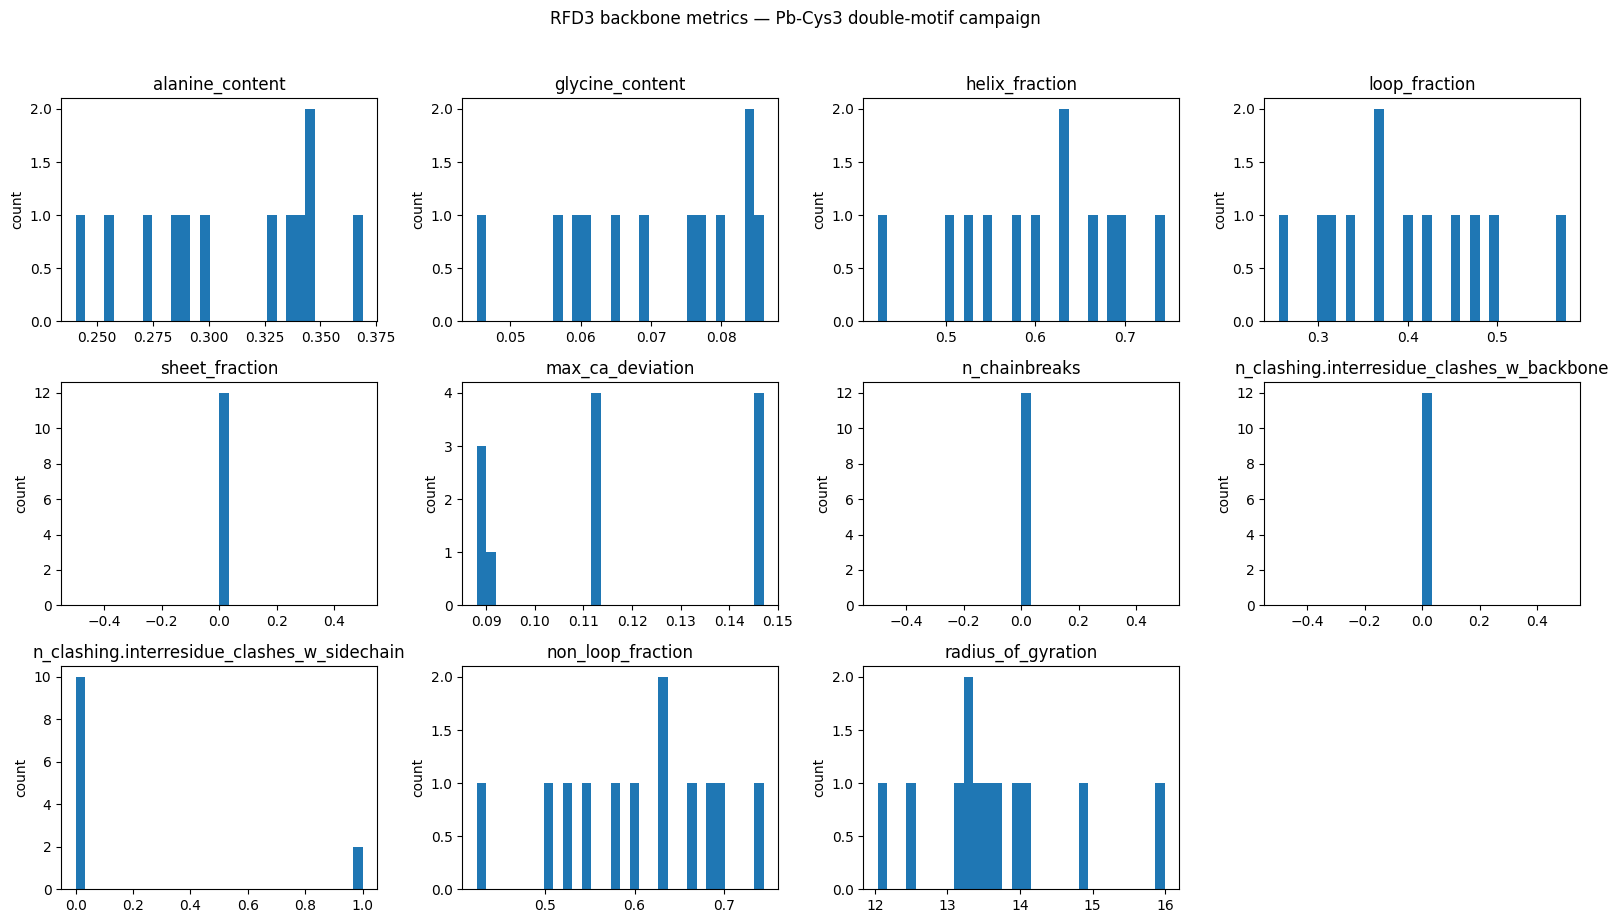

In [7]:
metrics = [
    "alanine_content", "glycine_content", "helix_fraction", "loop_fraction",
    "sheet_fraction", "max_ca_deviation", "n_chainbreaks",
    "n_clashing.interresidue_clashes_w_backbone",
    "n_clashing.interresidue_clashes_w_sidechain",
    "non_loop_fraction", "radius_of_gyration",
]
metrics = [m for m in metrics if m in df_rfd3.columns]
print("Plotting:", metrics)

if metrics:
    n_cols = 4
    n_rows = math.ceil(len(metrics) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()
    for ax, col in zip(axes, metrics):
        series = df_rfd3[col].dropna()
        if series.empty:
            ax.axis("off"); continue
        ax.hist(series, bins=30)
        ax.set_title(col)
        ax.set_ylabel("count")
    for ax in axes[len(metrics):]:
        ax.axis("off")
    plt.suptitle("RFD3 backbone metrics — Pb-Cys3 double-motif campaign", y=1.02)
    plt.tight_layout()
    plt.show()


### Optional backbone filtering

In [8]:
df_filt = df_rfd3.copy()

if "loop_fraction" in df_filt.columns:
    df_filt = df_filt[df_filt["loop_fraction"] < 0.4]
if "non_loop_fraction" in df_filt.columns:
    df_filt = df_filt[df_filt["non_loop_fraction"] > 0.6]
if "n_clashing.interresidue_clashes_w_backbone" in df_filt.columns:
    df_filt = df_filt[df_filt["n_clashing.interresidue_clashes_w_backbone"] == 0]
if "n_clashing.interresidue_clashes_w_sidechain" in df_filt.columns:
    df_filt = df_filt[df_filt["n_clashing.interresidue_clashes_w_sidechain"] == 0]

df_filt = df_filt[df_filt["structure_path"].astype(str).str.len() > 0].copy()

print(f"Total RFD3 designs  : {len(df_rfd3)}")
print(f"Passing backbones   : {len(df_filt)}")

passing_csv = scores_dir / "rfd3_passing_backbones.csv"
df_filt.to_csv(passing_csv, index=False)
print(f"Passing CSV         : {passing_csv}")
df_filt.head()


Total RFD3 designs  : 12
Passing backbones   : 5
Passing CSV         : /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/scores/rfd3_passing_backbones.csv


,condition,json_path,structure_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
4,ori15A_single_double_ori15A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.288660,-0.075249,-1.915749,-6.766802,0.157115,0.186830,0.994045,0.056701,0.661290,0.338710,0.087989,0,0,0,0.661290,194,8,14.130576,0.0
6,ori15A_single_double_ori15A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.346734,-3.074950,-1.524511,-4.815134,0.157115,0.186830,0.994045,0.080402,0.744186,0.255814,0.090671,0,0,0,0.744186,199,6,14.906543,0.0
8,ori18A_single_double_ori18A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.368984,-0.985032,-0.203443,-5.134616,0.156522,0.189579,0.993809,0.058824,0.692308,0.307692,0.113349,0,0,0,0.692308,187,6,13.890870,0.0
9,ori18A_single_double_ori18A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.284848,-1.103807,-1.395717,-6.489175,0.156522,0.189579,0.993809,0.060606,0.684211,0.315789,0.113349,0,0,0,0.684211,165,6,12.482072,0.0
11,ori18A_single_double_ori18A_rot180deg,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,0.338710,-0.711999,-0.558167,-1.777583,0.156522,0.189579,0.993809,0.086022,0.629310,0.370690,0.113349,0,0,0,0.629310,186,5,13.455353,0.0


## 4. ProteinMPNN — design sequences on scaffold chain A

ProteinMPNN redesigns only **chain A** (the generated scaffold).

Chains C, D (original motif) and X, Y (copied motif) are fixed context and must not be redesigned.
Fixed residues for ProteinMPNN are read from  in the RFD3 output JSON,
covering both Cys3 copies.


In [19]:
df_mpnn_input = df_filt.copy() if len(df_filt) > 0 else df_rfd3.copy()
df_mpnn_input = df_mpnn_input[df_mpnn_input["structure_path"].astype(str).str.len() > 0].copy()

if df_mpnn_input.empty:
    raise SystemExit("No RFD3 structures available for MPNN.")

# Motif 1: original Cys3 from 5GPE (chains C, D).
MOTIF1_FIXED_KEYS = ["C78", "C82", "D113", "D122"]

# Motif 2: copied Cys3 (chains X, Y — same residue numbers, different chains).
# These keys come from the chain_map applied by the prepare script.
# Default chain map: C->X, D->Y, so residue numbers are identical.
MOTIF2_FIXED_KEYS = ["X78", "X82", "Y113", "Y122"]

ALL_MOTIF_FIXED_KEYS = MOTIF1_FIXED_KEYS + MOTIF2_FIXED_KEYS

mpnn_cmds = cmds_dir / "mpnn.cmds"
fixed_report_rows = []

with mpnn_cmds.open("w") as handle:
    for _, row in df_mpnn_input.iterrows():
        structure = Path(row["structure_path"])
        condition = row["condition"]
        backbone_name = structure.name.replace(".cif.gz", "").replace(".cif", "")
        this_out = mpnn_out_dir / condition / backbone_name
        this_out.mkdir(parents=True, exist_ok=True)

        json_path = Path(row["json_path"])
        if not json_path.exists():
            raise FileNotFoundError(f"Missing RFD3 JSON: {json_path}")

        with json_path.open() as f:
            rfd3_data = json.load(f)

        mapping = rfd3_data["diffused_index_map"]

        # Fix residues from both motif copies.
        # Keys present in mapping depend on what RFD3 tracked; skip missing ones with a warning.
        fixed_keys_found = []
        fixed_keys_missing = []
        for key in ALL_MOTIF_FIXED_KEYS:
            if key in mapping:
                fixed_keys_found.append(key)
            else:
                fixed_keys_missing.append(key)

        if fixed_keys_missing:
            print(f"[WARNING] {backbone_name}: keys not in mapping: {fixed_keys_missing}")

        if not fixed_keys_found:
            raise KeyError(f"No motif keys found in diffused_index_map for {json_path}")

        # ProteinMPNN-style fixed residue strings are normally space-separated.
        # Build fixed residue IDs from the RFD3 residue mapping.
        fixed_residue_ids = [mapping[key] for key in fixed_keys_found]
        fixed_residues_report = ",".join(fixed_residue_ids)

        config_path = this_out / f"{backbone_name}_mpnn_config.json"

        mpnn_config = {
            "model_type": "protein_mpnn",
            "checkpoint_path": str(PROTEINMPNN_CKPT),
            "is_legacy_weights": True,
            "out_directory": str(this_out),
            "seed": MPNN_SEED,
            "batch_size": MPNN_BATCH_SIZE,
            "number_of_batches": MPNN_NUMBER_OF_BATCHES,
            "inputs": [
                {
                    "structure_path": str(structure),
                    "name": backbone_name,
                    "fixed_residues": fixed_residue_ids,
                }
            ],
        }

        with config_path.open("w") as f:
            json.dump(mpnn_config, f, indent=2)

        fixed_report_rows.append(
            {
                "condition": condition,
                "backbone_name": backbone_name,
                "structure_path": str(structure),
                "json_path": str(json_path),
                "config_path": str(config_path),
                "fixed_keys": ",".join(fixed_keys_found),
                "missing_keys": ",".join(fixed_keys_missing),
                "fixed_residues": fixed_residues_report,
            }
        )

        cmd = f'mpnn --config_json "{config_path}"'
        handle.write(cmd + "\n")

df_fixed_report = pd.DataFrame(fixed_report_rows)
fixed_report_path = scores_dir / "mpnn_fixed_residues_report.csv"
df_fixed_report.to_csv(fixed_report_path, index=False)

activate_mpnn = f"""
source "{CONDA_SH}"
conda activate "{MPNN_CONDA_ENV}"
"""

exports_mpnn = """
export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
"""

mpnn_script = write_lsf_array_script(
    cmds_path=mpnn_cmds,
    script_path=submit_dir / "mpnn.sh",
    job_name="mpnn_pb_double_fixed_cys3",
    queue=QUEUE,
    cores=4,
    mem="10GB",
    time_limit="2:00",
    group_size=10,
    gpu_spec=None,
    activate_lines=activate_mpnn,
    extra_exports=exports_mpnn,
)

print(f"Wrote {mpnn_cmds}")
print(f"Wrote {mpnn_script}")
print(f"Fixed report: {fixed_report_path}")
print(f"Backbones going to MPNN: {len(df_mpnn_input)}")
print(f"Sequences per backbone : {MPNN_BATCH_SIZE * MPNN_NUMBER_OF_BATCHES}")
print("\nFixed residues preview:")
display(df_fixed_report.head(20))
print("\nSubmit:")
print(f"  bsub < {mpnn_script}")


Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/cmds/mpnn.cmds
Wrote /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/mpnn.sh
Fixed report: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/scores/mpnn_fixed_residues_report.csv
Backbones going to MPNN: 5
Sequences per backbone : 4

Fixed residues preview:


,condition,backbone_name,structure_path,json_path,config_path,fixed_keys,missing_keys,fixed_residues
0,ori15A_single_double_ori15A_rot180deg,rfd3_input_ori15A_single_double_ori15A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122,X78,X82,Y113,Y122",,"A48,A52,A79,A88,A121,A125,A153,A162"
1,ori15A_single_double_ori15A_rot180deg,rfd3_input_ori15A_single_double_ori15A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122,X78,X82,Y113,Y122",,"A50,A54,A68,A77,A101,A105,A134,A143"
2,ori18A_single_double_ori18A_rot180deg,rfd3_input_ori18A_single_double_ori18A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122,X78,X82,Y113,Y122",,"A46,A50,A76,A85,A106,A110,A129,A138"
3,ori18A_single_double_ori18A_rot180deg,rfd3_input_ori18A_single_double_ori18A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122,X78,X82,Y113,Y122",,"A18,A22,A37,A46,A78,A82,A108,A117"
4,ori18A_single_double_ori18A_rot180deg,rfd3_input_ori18A_single_double_ori18A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,"C78,C82,D113,D122,X78,X82,Y113,Y122",,"A57,A61,A76,A85,A113,A117,A133,A142"



Submit:
  bsub < /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/mpnn.sh


In [26]:
# Run after the MPNN job finishes.
fa_files = sorted(mpnn_out_dir.glob("**/*.fa"))
print(f"Found {len(fa_files)} FASTA file(s) under {mpnn_out_dir}")
for path in fa_files[:10]:
    print(" ", path)
if len(fa_files) > 10:
    print(f"  ... and {len(fa_files) - 10} more")
if not fa_files:
    print("No FASTAs found yet. Submit MPNN first, wait for it to finish, then rerun this cell.")


Found 5 FASTA file(s) under /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/mpnn_out
  /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/mpnn_out/ori15A_single_double_ori15A_rot180deg/rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_0_model_0/rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_0_model_0.fa
  /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/mpnn_out/ori15A_single_double_ori15A_rot180deg/rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_2_model_0/rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_2_model_0.fa
  /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/mpnn_out/ori18A_single_double_ori18A_rot180deg/rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_m

## 5. RF3 — fold scaffold + SpyTag with Pb-Cys₃ context

RF3 folds:



For double-motif designs, RF3 receives only the scaffold sequence (chain A).
The fixed Pb-Cys₃ context (chains C/D and X/Y) is not passed as a separate chain to RF3 —
validation is done post-hoc via RMSD against the preparation-stage double-motif PDB.


In [ ]:
rf3_json_dir = Path(configs_dir) / "rf3"
rf3_json_dir.mkdir(parents=True, exist_ok=True)


def make_monomer_rf3_json(name: str, seq: str) -> dict:
    return {
        "name": name,
        "components": [{"chain_id": "A", "seq": seq}],
    }


DESIGN_RE = re.compile(r"_b(\d+)_d(\d+)")


def parse_fasta(path):
    header, chunks = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(chunks)
                header, chunks = line[1:], []
            else:
                chunks.append(line)
        if header is not None:
            yield header, "".join(chunks)


fa_files = sorted(glob.glob(os.path.join(mpnn_out_dir, "**", "*.fa"), recursive=True))
if not fa_files:
    raise SystemExit(f"No MPNN FASTAs under {mpnn_out_dir} — run MPNN first.")

written = 0
rf3_manifest_rows = []

for fa in fa_files:
    model_dir = os.path.basename(os.path.dirname(fa))
    for header, seq in parse_fasta(fa):
        m = DESIGN_RE.search(header)
        if not m:
            continue
        batch_idx = int(m.group(1))
        design_idx = int(m.group(2))
        chain_a = seq.split(":", 1)[0]
        name = f"{model_dir}__b{batch_idx}_d{design_idx}"
        j = make_monomer_rf3_json(name=name, seq=chain_a + SPYTAG)
        out_json = rf3_json_dir / f"{name}.json"
        with open(out_json, "w") as out:
            json.dump(j, out, indent=2)
        rf3_manifest_rows.append({
            "name": name,
            "rf3_json": str(out_json.resolve()),
            "mpnn_fasta": str(Path(fa).resolve()),
            "sequence": chain_a,
            "sequence_with_spytag": chain_a + SPYTAG,
            "sequence_length": len(chain_a),
        })
        written += 1

rf3_manifest = pd.DataFrame(rf3_manifest_rows)
rf3_manifest_path = configs_dir / "rf3_manifest.csv"
rf3_manifest.to_csv(rf3_manifest_path, index=False)

print(f"Wrote {written} RF3 input JSONs -> {rf3_json_dir}")
print(f"RF3 manifest: {rf3_manifest_path}")
rf3_manifest.head()


Wrote 5 RF3 input JSONs -> /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/configs/rf3
RF3 manifest: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/configs/rf3_manifest.csv


,name,rf3_json,mpnn_fasta,sequence,sequence_with_spytag,sequence_length
0,rfd3_input_ori15A_single_double_ori15A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,NLERLARCAANLERVRAELDAAFPDAPAAARARLDLFIHLARNPEL...,NLERLARCAANLERVRAELDAAFPDAPAAARARLDLFIHLARNPEL...,194
1,rfd3_input_ori15A_single_double_ori15A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,KLEEVQEILDLALEKTKARLTALAAAHTPEELAAGLATLARLAAAP...,KLEEVQEILDLALEKTKARLTALAAAHTPEELAAGLATLARLAAAP...,199
2,rfd3_input_ori18A_single_double_ori18A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,MSRAARIREGAALLAELLAWLGVDPALAARFAELLAAAAEAPDAPC...,MSRAARIREGAALLAELLAWLGVDPALAARFAELLAAAAEAPDAPC...,187
3,rfd3_input_ori18A_single_double_ori18A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,SALAAAMAALKANPALPCAPCNALFADLPVPALLALCGPDETCADC...,SALAAAMAALKANPALPCAPCNALFADLPVPALLALCGPDETCADC...,165
4,rfd3_input_ori18A_single_double_ori18A_rot180d...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,/dtu/blackhole/00/222976/lead_sensoring/work/e...,MSLDEAVAAAVAAGWNERGVAGLAALVALARGKDAAVALLEIMVAS...,MSLDEAVAAAVAAGWNERGVAGLAALVALARGKDAAVALLEIMVAS...,186


In [25]:
from pathlib import Path
import math
import shlex

# ------------------------------------------------------------
# RF3 LSF settings
# ------------------------------------------------------------

queue = "c27666"
job_name = "rf3"
time_limit = "2:00"
mem = "10GB"
gpu_spec = "num=1:mode=exclusive_process"
cores = 4
group_size = 20

# ------------------------------------------------------------
# RF3 paths
# ------------------------------------------------------------

rf3_release = Path("/dtu/projects/dbl/rf3/release")
ckpt_path = rf3_release / "ckpt/rf3_latest.pt"
num_steps = 50

rf3_json_dir = Path(rf3_json_dir)
rf3_out_dir = Path(rf3_out_dir)
cmds_dir = Path(cmds_dir)
submit_dir = Path(submit_dir)
logs_dir = Path(logs_dir)

cmds_dir.mkdir(parents=True, exist_ok=True)
submit_dir.mkdir(parents=True, exist_ok=True)
logs_dir.mkdir(parents=True, exist_ok=True)
rf3_out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Optional RF3 patch path
# ------------------------------------------------------------
# This should point to the folder where your monkeypatch file lives.
# If you do not need the patch, set it to an empty string.
try:
    rf3_patch_dir = Path(rf3_patch_dir)
    use_rf3_patch = str(rf3_patch_dir).strip() != ""
except NameError:
    rf3_patch_dir = None
    use_rf3_patch = False

# ------------------------------------------------------------
# Collect RF3 input JSON files
# ------------------------------------------------------------

json_files = sorted(rf3_json_dir.glob("*.json"))

if not json_files:
    raise SystemExit(f"No RF3 JSONs found in {rf3_json_dir}")

cmds_path = cmds_dir / "rf3.cmds"

# ------------------------------------------------------------
# Write RF3 command file
# ------------------------------------------------------------

lines = []

for jf in json_files:
    out_dir = rf3_out_dir / jf.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd_parts = [
        "python",
        str(Path(REPO_ROOT) / "scripts/lib/rf3_wrapper.py"),
        "fold",
        "inference_engine=rf3",
        f"inputs={jf}",
        f"out_dir={out_dir}",
        f"ckpt_path={ckpt_path}",
        f"num_steps={num_steps}",
        "annotate_b_factor_with_plddt=True",
        "early_stopping_plddt_threshold=0",
    ]

    # Quote each shell token safely.
    cmd = " ".join(shlex.quote(str(x)) for x in cmd_parts)
    lines.append(cmd)

cmds_path.write_text("\n".join(lines) + "\n")

n_arrays = math.ceil(len(lines) / group_size)

# ------------------------------------------------------------
# Write RF3 LSF array script
# ------------------------------------------------------------

patch_export = ""
if use_rf3_patch:
    patch_export = f'export PYTHONPATH="{rf3_patch_dir}:${{PYTHONPATH}}"\n'

script = f"""#!/bin/bash
#BSUB -q {queue}
#BSUB -J {job_name}[1-{n_arrays}]
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J_%I.out
#BSUB -e {logs_dir}/%J_%I.err

set -euo pipefail

mkdir -p {shlex.quote(str(logs_dir))}
mkdir -p {shlex.quote(str(rf3_out_dir))}

module load cuda/12.4

# RF3 activate_env.sh expects PYTHONPATH to exist.
export PYTHONPATH="${{PYTHONPATH:-}}"

# Optional monkeypatch before RF3 imports cuequivariance.
{patch_export}
# RF3 uses its own dedicated environment, not a conda env called rf3.
set +u
source {shlex.quote(str(rf3_release / "activate_env.sh"))}
set -u

export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

CMDS_FILE={shlex.quote(str(cmds_path))}
GROUP_SIZE={group_size}
START=$(( (LSB_JOBINDEX - 1) * GROUP_SIZE ))
END=$(( START + GROUP_SIZE ))

echo "Job index: $LSB_JOBINDEX"
echo "Command range: $START to $((END - 1))"
echo "Commands file: $CMDS_FILE"
echo "Started at $(date)"

i=0
while IFS= read -r cmd; do
    if [ "$i" -ge "$START" ] && [ "$i" -lt "$END" ]; then
        echo "----------------------------------------"
        echo "Running command index $i"
        echo "$cmd"
        eval "$cmd"
    fi
    i=$((i+1))
done < "$CMDS_FILE"

echo "Done at $(date)"
"""

sub = submit_dir / "rf3.sh"
sub.write_text(script)

print(f"{len(lines)} RF3 folds in {n_arrays} array task(s).")
print(f"Commands: {cmds_path}")
print(f"LSF script: {sub}")
print("\nCheck first command:")
print(f"  head -n 1 {cmds_path}")
print("\nCheck activation:")
print(f"  grep -n \"activate_env\" {sub}")
print("\nSubmit:")
print(f"  bsub < {sub}")

5 RF3 folds in 1 array task(s).
Commands: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/cmds/rf3.cmds
LSF script: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/rf3.sh

Check first command:
  head -n 1 /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/cmds/rf3.cmds

Check activation:
  grep -n "activate_env" /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/rf3.sh

Submit:
  bsub < /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/submit/rf3.sh


## 6. Gather RF3 metrics

Run after RF3 jobs finish.


In [27]:
def flatten_scalar_dict(d, prefix=""):
    out = {}
    if not isinstance(d, dict):
        return out
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)
        if isinstance(v, dict):
            out.update(flatten_scalar_dict(v, key))
        elif isinstance(v, (str, int, float, bool)) or v is None:
            out[key] = v
        elif isinstance(v, list) and len(v) <= 20:
            out[key] = str(v)
    return out


def read_score_or_json(path):
    text = Path(path).read_text().strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    data = {}
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if ":" in line:
            k, v = line.split(":", 1)
        else:
            parts = line.split(None, 1)
            if len(parts) != 2:
                continue
            k, v = parts
        k = k.strip(); v = v.strip()
        try:
            v = float(v)
        except ValueError:
            pass
        data[k] = v
    return data


OUT_CSV = scores_dir / "rf3_gathered_scores.csv"
rows = []
score_files = sorted(Path(rf3_out_dir).glob("**/*.score"))
json_files = sorted(Path(rf3_out_dir).glob("**/*.json"))

print("Score files:", len(score_files))
print("JSON files:", len(json_files))

for p in score_files:
    try:
        data = read_score_or_json(p)
    except Exception as exc:
        print(f"[WARNING] Could not read {p}: {exc}")
        continue
    row = flatten_scalar_dict(data)
    row["score_file"] = str(p)
    row["design_id"] = p.parent.name
    row["model_idx"] = int(re.search(r"model_(\d+)", p.stem).group(1)) if re.search(r"model_(\d+)", p.stem) else -1
    row["rf3_structure_path"] = str(p.with_suffix(".pdb")) if p.with_suffix(".pdb").exists() else ""
    rows.append(row)

if not rows:
    print("No RF3 results yet. Submit RF3 first.")
else:
    df_rf3_scores = pd.DataFrame(rows)
    df_rf3_scores.to_csv(OUT_CSV, index=False)
    print(f"Wrote {len(df_rf3_scores)} rows -> {OUT_CSV}")
    display(df_rf3_scores.head())


Score files: 5
JSON files: 0
Wrote 5 rows -> /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/scores/rf3_gathered_scores.csv


,score_file,design_id,model_idx,rf3_structure_path
0,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_ori15A_single_double_ori15A_rot180d...,0,
1,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_ori15A_single_double_ori15A_rot180d...,0,
2,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_ori18A_single_double_ori18A_rot180d...,0,
3,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_ori18A_single_double_ori18A_rot180d...,0,
4,/dtu/blackhole/00/222976/lead_sensoring/work/e...,rfd3_input_ori18A_single_double_ori18A_rot180d...,0,


## 7. Score and rank designs

RMSD is computed between the RF3 output (scaffold chain A) and both Cys3 motif copies
from the preparation-stage double-motif PDB.

Both copies are evaluated independently. A design passes if **both** copies preserve the Cys3 triad.


In [32]:
import biotite.structure as struc
from biotite.structure.io.pdb import PDBFile
from biotite.structure.io import load_structure as bio_load


def load_atom_array(path):
    path = Path(path)
    if path.suffix in (".gz",):
        import gzip
        with gzip.open(path) as f:
            content = f.read().decode()
        tmp = Path("/tmp/_tmp_load.cif")
        tmp.write_text(content)
        return bio_load(str(tmp))
    return bio_load(str(path))


def get_atom_coord(arr, chain, res_id, atom_name):
    mask = (arr.chain_id == chain) & (arr.res_id == res_id) & (arr.atom_name == atom_name)
    if mask.sum() == 0:
        raise KeyError(f"{chain}{res_id} {atom_name} not found")
    return arr.coord[mask][0]


def kabsch_rmsd(P, Q):
    P = P - P.mean(0); Q = Q - Q.mean(0)
    H = P.T @ Q
    U, _, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T
    return float(np.sqrt(((P @ R.T - Q) ** 2).mean()))


def parse_chain_res(label):
    """Parse labels like A42 or X113."""
    m = re.match(r"([A-Za-z]+)(\d+)", label)
    if not m:
        raise ValueError(f"Cannot parse label: {label}")
    return m.group(1), int(m.group(2))


BACKBONE_ATOMS = ["N", "CA", "C", "O"]

# Motif 1 keys (original, chains C/D)
MOTIF1_KEYS = ["C78", "D113", "D122"]   # Cys3 only for RMSD
# Motif 2 keys (copy, chains X/Y)
MOTIF2_KEYS = ["X78", "Y113", "Y122"]

PTM_CUT          = 0.80
CYS3_RMSD_CUT    = 1.00
LOCAL_SCORE_CUT  = 0.60


def rmsd_to_score(x, scale):
    x = np.asarray(x, dtype=float)
    return float(np.exp(-0.5 * (x / scale) ** 2))


# Build rfd3_records from diffusion output JSONs for mapping.
# Important: RF3 design IDs contain longer prefixes than the raw RFD3 JSON stem,
# so we store multiple aliases pointing to the same record.

def make_rfd3_aliases(json_stem, condition):
    """Return possible IDs that can refer to the same RFD3 design."""
    aliases = set()

    json_stem = str(json_stem)
    condition = str(condition)

    aliases.add(json_stem)

    # Remove common RF3/score suffixes if present.
    aliases.add(re.sub(r"__b\d+_d\d+$", "", json_stem))
    aliases.add(re.sub(r"_model_\d+$", "", json_stem))

    # Match tags such as ori13A, ori15A, ori18A.
    ori_match = re.search(r"ori\d+A", json_stem)

    if ori_match is not None:
        ori_tag = ori_match.group(0)

        # This matches the RF3-style source IDs seen in your warnings:
        # rfd3_input_ori15A_single_double_ori15A_rot180deg_<json_stem>
        rf3_prefix = f"rfd3_input_{ori_tag}_single_double_{ori_tag}_rot180deg"
        aliases.add(f"{rf3_prefix}_{json_stem}")

        # Also add a no-final-index version.
        no_index = re.sub(r"_\d+$", "", json_stem)
        aliases.add(no_index)
        aliases.add(f"{rf3_prefix}_{no_index}")

    # If condition is informative, also include condition-prefixed forms.
    if condition:
        aliases.add(f"{condition}_{json_stem}")

    return {a for a in aliases if a}


def add_rfd3_record_alias(records, alias, record):
    """Add an alias to rfd3_records without silently overwriting another design."""
    if alias in records:
        existing_json = records[alias].get("json_path", "")
        new_json = record.get("json_path", "")

        if existing_json != new_json:
            print(
                "[WARNING] Ambiguous RFD3 alias skipped:",
                alias,
                "| existing:",
                existing_json,
                "| new:",
                new_json,
            )
            return

    records[alias] = record


rfd3_records = {}
rfd3_primary_records = {}

for jp in sorted(diffusion_out_dir.glob("*/*.json")):
    with jp.open() as f:
        data = json.load(f)

    mapping = data.get("diffused_index_map", {})

    if not mapping:
        print("[WARNING] Empty diffused_index_map:", jp)
        continue

    primary_id = jp.stem
    condition = jp.parent.name

    record = {
        "primary_id": primary_id,
        "condition": condition,
        "mapping": mapping,
        "json_path": str(jp),
        "aliases": sorted(make_rfd3_aliases(primary_id, condition)),
    }

    rfd3_primary_records[primary_id] = record

    for alias in record["aliases"]:
        add_rfd3_record_alias(rfd3_records, alias, record)

print(f"Loaded {len(rfd3_primary_records)} primary RFD3 records with diffused_index_map")
print(f"Loaded {len(rfd3_records)} RFD3 lookup aliases")

print("\nExample primary IDs:")
for key in list(rfd3_primary_records.keys())[:10]:
    print(" ", key)

print("\nExample lookup aliases:")
for key in list(rfd3_records.keys())[:20]:
    print(" ", key)


Loaded 12 primary RFD3 records with diffused_index_map
Loaded 72 RFD3 lookup aliases

Example primary IDs:
  rfd3_input_ori13A_single_double_ori13A_rot180deg_5gpe_pb_motif_r5_ori13A_single_double_ori13A_rot180deg_0_model_0
  rfd3_input_ori13A_single_double_ori13A_rot180deg_5gpe_pb_motif_r5_ori13A_single_double_ori13A_rot180deg_1_model_0
  rfd3_input_ori13A_single_double_ori13A_rot180deg_5gpe_pb_motif_r5_ori13A_single_double_ori13A_rot180deg_2_model_0
  rfd3_input_ori13A_single_double_ori13A_rot180deg_5gpe_pb_motif_r5_ori13A_single_double_ori13A_rot180deg_3_model_0
  rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_0_model_0
  rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_1_model_0
  rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_2_model_0
  rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single

In [33]:
print("\nRF3 ID lookup test:")

for design_id in df_rf3_scores["design_id"].head(20):
    source_id = strip_rf3_design_suffix(design_id)
    print(source_id, "->", source_id in rfd3_records)


RF3 ID lookup test:
rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_0 -> True
rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_2 -> True
rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_0 -> True
rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_1 -> True
rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_3 -> True


In [37]:
print(df_rf3_scores[["design_id", "rf3_structure_path"]].to_string())

print("\nPath diagnostics:")
for i, row in df_rf3_scores.iterrows():
    raw = str(row.get("rf3_structure_path", ""))
    p = Path(raw)
    print({
        "i": i,
        "design_id": row["design_id"],
        "raw_path": repr(raw),
        "path": str(p),
        "exists": p.exists(),
        "is_file": p.is_file(),
        "suffix": p.suffix,
    })

                                                                                                                  design_id rf3_structure_path
0  rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_0_model_0__b0_d0                   
1  rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_2_model_0__b0_d0                   
2  rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_0_model_0__b0_d0                   
3  rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_1_model_0__b0_d0                   
4  rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_3_model_0__b0_d0                   

Path diagnostics:
{'i': 0, 'design_id': 'rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180

In [34]:
from pathlib import Path
import re
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

DOUBLE_MOTIF_REFERENCE_DIR = Path(
    "/dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01/double_motif_structures"
)

OUT_RMSD = Path(scores_dir) / "rf3_double_motif_vs_original_motif_rmsd.csv"

# Only the Pb-binding Cys3 residues.
# Do not include C82/X82 here if those residues are contextual and not CYS.
MOTIF1_CYS3_KEYS = ["C78", "D113", "D122"]
MOTIF2_CYS3_KEYS = ["X78", "Y113", "Y122"]

BACKBONE_RMSD_ATOMS = ["N", "CA", "C", "O"]
SG_RMSD_ATOMS = ["SG"]

if not DOUBLE_MOTIF_REFERENCE_DIR.exists():
    raise FileNotFoundError(
        f"Missing double-motif reference directory: {DOUBLE_MOTIF_REFERENCE_DIR}"
    )


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def strip_rf3_design_suffix(design_id):
    """Remove RF3 design suffixes to recover the source/backbone ID."""
    design_id = str(design_id)

    # Common RF3 suffix: __b0_d0
    design_id = re.sub(r"__b\d+_d\d+$", "", design_id)

    # Optional fallback if your score IDs contain model suffixes.
    design_id = re.sub(r"_model_\d+$", "", design_id)

    return design_id


def resolve_chain(atom_array, preferred_chain):
    """
    Return preferred_chain if present.

    If the structure only has one chain, use that single chain as fallback.
    This is useful when RF3 outputs everything as chain A.
    """
    chains = sorted(set(str(c) for c in atom_array.chain_id))

    if preferred_chain in chains:
        return preferred_chain

    if len(chains) == 1:
        return chains[0]

    raise KeyError(
        f"Chain {preferred_chain} not found. Available chains: {chains}"
    )


def get_original_double_motif_reference_path(source_id, rec):
    """Find the original double-motif PDB used to start this design."""
    pdb_files = sorted(DOUBLE_MOTIF_REFERENCE_DIR.glob("*.pdb"))

    if not pdb_files:
        raise FileNotFoundError(
            f"No PDB files found in {DOUBLE_MOTIF_REFERENCE_DIR}"
        )

    search_text = " ".join(
        str(x)
        for x in [
            source_id,
            rec.get("condition", ""),
            rec.get("backbone_name", ""),
            rec.get("name", ""),
            rec.get("structure_path", ""),
            rec.get("json_path", ""),
        ]
    )

    # First try exact stem match.
    for pdb in pdb_files:
        if pdb.stem == source_id:
            return pdb

    # Then match ori13A / ori15A / ori18A.
    ori_match = re.search(r"ori\d+A", search_text)

    if ori_match is not None:
        ori_tag = ori_match.group(0)
        matches = [p for p in pdb_files if ori_tag in p.stem]

        if len(matches) == 1:
            return matches[0]

        if len(matches) > 1:
            raise ValueError(
                f"Multiple reference PDBs matched {ori_tag}: {[p.name for p in matches]}"
            )

    # Last fallback: reference stem contained in source_id.
    matches = [p for p in pdb_files if p.stem in str(source_id)]

    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        "Could not identify original double-motif reference.\n"
        f"source_id: {source_id}\n"
        f"condition: {rec.get('condition', '')}\n"
        f"available references: {[p.name for p in pdb_files]}"
    )


def collect_original_motif_rmsd(rf3_arr, ref_arr, mapping, keys, atoms):
    """
    Compute RMSD between RF3 predicted motif and the original motif reference.

    RF3 side:
        mapping[key], e.g. C78 -> A48

    Reference side:
        key itself, e.g. C78 in the original double-motif PDB.
    """
    P = []
    Q = []
    used_atoms = []
    missing_atoms = []

    for key in keys:
        if key not in mapping:
            missing_atoms.append(f"{key}:missing_from_mapping")
            continue

        rf3_mapped_id = str(mapping[key])

        rf3_chain_raw, rf3_res = parse_chain_res(rf3_mapped_id)
        ref_chain_raw, ref_res = parse_chain_res(key)

        try:
            rf3_chain = resolve_chain(rf3_arr, rf3_chain_raw)
            ref_chain = resolve_chain(ref_arr, ref_chain_raw)
        except Exception as exc:
            missing_atoms.append(f"{key}->{rf3_mapped_id}:chain_error:{exc}")
            continue

        for atom in atoms:
            try:
                rf3_coord = get_atom_coord(
                    rf3_arr,
                    rf3_chain,
                    rf3_res,
                    atom,
                )

                ref_coord = get_atom_coord(
                    ref_arr,
                    ref_chain,
                    ref_res,
                    atom,
                )

                P.append(rf3_coord)
                Q.append(ref_coord)
                used_atoms.append(f"{key}->{rf3_mapped_id}@{atom}")

            except Exception:
                missing_atoms.append(f"{key}->{rf3_mapped_id}@{atom}")

    if len(P) < 3:
        return np.nan, len(P), ",".join(used_atoms), ",".join(missing_atoms)

    return (
        kabsch_rmsd(np.asarray(P), np.asarray(Q)),
        len(P),
        ",".join(used_atoms),
        ",".join(missing_atoms),
    )


def check_cys_preserved(rf3_arr, mapping, keys):
    """Check whether mapped RF3 residues are still CYS."""
    checked = []
    failed = []

    for key in keys:
        if key not in mapping:
            failed.append(f"{key}:missing_from_mapping")
            return False, ",".join(checked), ",".join(failed)

        mapped_id = str(mapping[key])
        chain_raw, res_id = parse_chain_res(mapped_id)

        try:
            chain = resolve_chain(rf3_arr, chain_raw)
        except Exception as exc:
            failed.append(f"{key}->{mapped_id}:chain_error:{exc}")
            return False, ",".join(checked), ",".join(failed)

        mask = (
            (rf3_arr.chain_id == chain)
            & (rf3_arr.res_id == res_id)
        )

        if mask.sum() == 0:
            failed.append(f"{key}->{mapped_id}:residue_not_found")
            return False, ",".join(checked), ",".join(failed)

        res_name = str(rf3_arr.res_name[mask][0])
        checked.append(f"{key}->{mapped_id}:{res_name}")

        if res_name != "CYS":
            failed.append(f"{key}->{mapped_id}:expected_CYS_found_{res_name}")
            return False, ",".join(checked), ",".join(failed)

    return True, ",".join(checked), ",".join(failed)


# ------------------------------------------------------------
# Main RMSD evaluation
# ------------------------------------------------------------

rmsd_rows = []

for _, row in df_rf3_scores.iterrows():
    design_id = row["design_id"]
    model_idx = int(row.get("model_idx", -1))
    rf3_path = Path(row["rf3_structure_path"])

    if not rf3_path.exists():
        print("[WARNING] Missing RF3 structure:", rf3_path)
        continue

    source_id = strip_rf3_design_suffix(design_id)

    if source_id not in rfd3_records:
        print("[WARNING] Missing RFD3 source:", source_id)
        continue

    rec = rfd3_records[source_id]

    if "mapping" not in rec:
        print("[WARNING] Missing mapping in RFD3 record:", source_id)
        continue

    mapping = rec["mapping"]

    try:
        rf3_arr = load_atom_array(rf3_path)

        ref_path = get_original_double_motif_reference_path(source_id, rec)
        ref_arr = load_atom_array(ref_path)

        kept_cys3_motif1, cys_checked1, cys_failed1 = check_cys_preserved(
            rf3_arr,
            mapping,
            MOTIF1_CYS3_KEYS,
        )

        kept_cys3_motif2, cys_checked2, cys_failed2 = check_cys_preserved(
            rf3_arr,
            mapping,
            MOTIF2_CYS3_KEYS,
        )

        kept_both = kept_cys3_motif1 and kept_cys3_motif2

        bb_rmsd1, bb_n1, bb_atoms1, bb_missing1 = collect_original_motif_rmsd(
            rf3_arr,
            ref_arr,
            mapping,
            MOTIF1_CYS3_KEYS,
            BACKBONE_RMSD_ATOMS,
        )

        bb_rmsd2, bb_n2, bb_atoms2, bb_missing2 = collect_original_motif_rmsd(
            rf3_arr,
            ref_arr,
            mapping,
            MOTIF2_CYS3_KEYS,
            BACKBONE_RMSD_ATOMS,
        )

        sg_rmsd1, sg_n1, sg_atoms1, sg_missing1 = collect_original_motif_rmsd(
            rf3_arr,
            ref_arr,
            mapping,
            MOTIF1_CYS3_KEYS,
            SG_RMSD_ATOMS,
        )

        sg_rmsd2, sg_n2, sg_atoms2, sg_missing2 = collect_original_motif_rmsd(
            rf3_arr,
            ref_arr,
            mapping,
            MOTIF2_CYS3_KEYS,
            SG_RMSD_ATOMS,
        )

        ptm = float(row.get("ptm", np.nan))

        passes = (
            np.isfinite(ptm)
            and ptm >= PTM_CUT
            and kept_both
            and np.isfinite(bb_rmsd1)
            and np.isfinite(bb_rmsd2)
            and np.isfinite(sg_rmsd1)
            and np.isfinite(sg_rmsd2)
            and bb_rmsd1 <= CYS3_RMSD_CUT
            and bb_rmsd2 <= CYS3_RMSD_CUT
            and sg_rmsd1 <= CYS3_RMSD_CUT
            and sg_rmsd2 <= CYS3_RMSD_CUT
        )

        rmsd_rows.append(
            {
                "design_id": design_id,
                "source_id": source_id,
                "condition": rec.get("condition", ""),
                "model_idx": model_idx,
                "ptm": ptm,

                "rf3_structure_path": str(rf3_path),
                "original_motif_reference_path": str(ref_path),

                "kept_cys3_motif1": kept_cys3_motif1,
                "kept_cys3_motif2": kept_cys3_motif2,
                "kept_both_cys3": kept_both,

                "cys_checked_motif1": cys_checked1,
                "cys_checked_motif2": cys_checked2,
                "cys_failed_motif1": cys_failed1,
                "cys_failed_motif2": cys_failed2,

                "cys3_backbone_rmsd_motif1": bb_rmsd1,
                "cys3_backbone_rmsd_motif2": bb_rmsd2,
                "cys3_sg_rmsd_motif1": sg_rmsd1,
                "cys3_sg_rmsd_motif2": sg_rmsd2,

                "n_backbone_atoms_motif1": bb_n1,
                "n_backbone_atoms_motif2": bb_n2,
                "n_sg_atoms_motif1": sg_n1,
                "n_sg_atoms_motif2": sg_n2,

                "backbone_atoms_motif1": bb_atoms1,
                "backbone_atoms_motif2": bb_atoms2,
                "sg_atoms_motif1": sg_atoms1,
                "sg_atoms_motif2": sg_atoms2,

                "missing_backbone_atoms_motif1": bb_missing1,
                "missing_backbone_atoms_motif2": bb_missing2,
                "missing_sg_atoms_motif1": sg_missing1,
                "missing_sg_atoms_motif2": sg_missing2,

                "cys3_backbone_score_motif1": rmsd_to_score(
                    bb_rmsd1,
                    CYS3_RMSD_CUT,
                ),
                "cys3_backbone_score_motif2": rmsd_to_score(
                    bb_rmsd2,
                    CYS3_RMSD_CUT,
                ),
                "cys3_sg_score_motif1": rmsd_to_score(
                    sg_rmsd1,
                    CYS3_RMSD_CUT,
                ),
                "cys3_sg_score_motif2": rmsd_to_score(
                    sg_rmsd2,
                    CYS3_RMSD_CUT,
                ),

                "passes_first_triage": passes,
            }
        )

    except Exception as exc:
        print("[FAILED]", design_id, exc)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df_rmsd = pd.DataFrame(rmsd_rows)
df_rmsd.to_csv(OUT_RMSD, index=False)

print("Evaluated:", len(df_rmsd))

if len(df_rmsd) > 0:
    print("Passing first triage:", int(df_rmsd["passes_first_triage"].sum()))
else:
    print("Passing first triage: 0")

print("Saved:", OUT_RMSD)

display(df_rmsd.head())

[FAILED] rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_0_model_0__b0_d0 Unknown file format ''
[FAILED] rfd3_input_ori15A_single_double_ori15A_rot180deg_5gpe_pb_motif_r5_ori15A_single_double_ori15A_rot180deg_2_model_0__b0_d0 Unknown file format ''
[FAILED] rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_0_model_0__b0_d0 Unknown file format ''
[FAILED] rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_1_model_0__b0_d0 Unknown file format ''
[FAILED] rfd3_input_ori18A_single_double_ori18A_rot180deg_5gpe_pb_motif_r5_ori18A_single_double_ori18A_rot180deg_3_model_0__b0_d0 Unknown file format ''
Evaluated: 0
Passing first triage: 0
Saved: /dtu/blackhole/00/222976/lead_sensoring/work/exp_doubles_01_rfd3_mpnn_rf3/scores/rf3_double_motif_vs_original_motif_rmsd.csv


""


### Plots

In [ ]:
PLOTS_DIR = WORK / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(fig, filename, dpi=300):
    out_path = PLOTS_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {out_path}")

df = df_rmsd.copy()

# Plot: RMSD motif1 vs motif2, coloured by pTM
x = df["cys3_backbone_rmsd_motif1"].to_numpy(float)
y = df["cys3_backbone_rmsd_motif2"].to_numpy(float)
c = df["ptm"].to_numpy(float)
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(x[mask], y[mask], c=c[mask], s=30, alpha=0.85,
                linewidths=0, cmap="viridis", vmin=0, vmax=1)
ax.axvline(CYS3_RMSD_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
ax.axhline(CYS3_RMSD_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
ax.set_xlabel("Cys3 RMSD — motif 1 (Å)")
ax.set_ylabel("Cys3 RMSD — motif 2 (Å)")
ax.set_title("Both Cys3 motif copy conservation")
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
fig.colorbar(sc, ax=ax).set_label("RF3 pTM")
fig.tight_layout()
save_plot(fig, "plot_01_motif1_vs_motif2_rmsd.png")
plt.show()

# Plot: pTM distribution coloured by both_cys3
fig, ax = plt.subplots(figsize=(7, 4))
for kept, label, color in [(True, "Both Cys3 kept", "steelblue"), (False, "Cys3 lost", "tomato")]:
    sub = df[df["kept_both_cys3"] == kept]["ptm"].dropna()
    ax.hist(sub, bins=20, alpha=0.7, label=label, color=color)
ax.axvline(PTM_CUT, color="k", lw=0.9, ls="--", alpha=0.6)
ax.set_xlabel("RF3 pTM"); ax.set_ylabel("Count")
ax.set_title("pTM distribution by Cys3 conservation")
ax.legend(); ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
fig.tight_layout()
save_plot(fig, "plot_02_ptm_by_cys3_conservation.png")
plt.show()


In [ ]:
df_ranked = df_rmsd.sort_values(
    ["passes_first_triage", "cys3_backbone_rmsd_motif1", "cys3_backbone_rmsd_motif2", "ptm"],
    ascending=[False, True, True, False],
).copy()

OUT_RANKED = scores_dir / "rf3_double_motif_rmsd_ranked.csv"
df_ranked.to_csv(OUT_RANKED, index=False)
print("Saved:", OUT_RANKED)

df_ranked[[
    "design_id", "condition", "ptm",
    "passes_first_triage", "kept_both_cys3",
    "cys3_backbone_rmsd_motif1", "cys3_backbone_rmsd_motif2",
    "rf3_structure_path",
]].head(10)
